# Asystent Zdrowia i Kalkulator BMI
**Projekt zaliczeniowy - Python**  
**Autor:** Piotr Bacior (15 722) | **Rok:** 2026 | **Prowadząca:** 	mgr Marzena Halama

Witaj w interaktywnej prezentacji mojego projektu! Ten notatnik przeprowadzi Cię przez wszystkie etapy budowy aplikacji: od podstawowej logiki matematycznej, przez obsługę plików i baz danych, aż po interaktywne wykresy i testy jednostkowe.

---
### Krok 1: Importy bibliotek
Na początku importujemy wszystkie narzędzia, których użyjemy w projekcie. Zawarłem tu biblioteki standardowe (np. `os`, `csv`, `datetime`) oraz zewnętrzne potęgi Data Science (`pandas`, `matplotlib`).

In [1]:
import os
import csv
import tempfile
import unittest
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

print("Pomyślnie zaimportowano wszystkie biblioteki!")

Pomyślnie zaimportowano wszystkie biblioteki!


---
### Krok 2: Moduł Kalkulatora (Logika Matematyczna)
To "mózg" naszej aplikacji. Zawarłem tutaj funkcje odpowiedzialne za czystą matematykę:
1. Obliczanie BMI - Body Mass Index - Wskaźnik Masy Ciała - waga / wzrost^2.
2. Wyliczanie granic idealnej wagi.
3. Obliczanie BMR - Basal Metabolic Rate - Podstawowa Przemiana Materii - (wzorem Mifflin-St Jeor).
4. Obliczanie całkowitego zapotrzebowania (TDEE) - Total Daily Energy Expenditure - Całkowite Dzienne Zapotrzebowanie Energetyczne.
Każda funkcja posiada walidację danych (broni się przed zerami i ujemnymi wartościami).

In [2]:
def calculate_bmi(weight_kg: float, height_m: float) -> float: 

    """
    Oblicza BMI na podstawie wagi (w kilogramach) i wzrostu (w metrach)
    
    Oczekiwane dane wejściowe:
    - weight_kg: waga w kilogramach (float)
    - height_m: wzrost w metrach (float)

    Zachowanie funkcji:
    - Oblicza stosunek wagi do kwadratu wzrostu (BMI = waga / (wzrost^2))
    - Zwraca wskaźnik BMI jako wartość zmiennoprzecinkową (float)

    Ograniczenia: 
    - Oczekiwane wartosci 'weight_kg' i 'height_m' muszą być dodatnie (> 0)

    Podnoszenie wyjątków:
    - ValueError: jeśli 'weight_kg' lub 'height_m' jest mniejsze lub równe 0

    """

    if weight_kg <= 0: raise ValueError("Waga musi być większa niż 0.")
    if height_m <= 0: raise ValueError("Wzrost musi być większy niż 0.")
    bmi = weight_kg / (height_m ** 2)           
    return round(bmi, 2)                        



def calculate_ideal_weight(height_m: float) -> tuple[float, float]:

    """
    Oblicza zakres idealnej wagi dla danego wzrostu w metrach

    Oczekiwane dane wejściowe:
    - height_m: wzrost w metrach (float)

    Zachowanie funkcji:
    - Wykorzystuje minimalne (18.5) i maksymalne (24.9) wartości BMI, aby obliczyć dolną i górną granicę idealnej wagi
    - Zwraca dwuelementową krotkę (tuple) zawierającą dolną i górną granicę idealnej wagi w kilogramach (float)

    Ograniczenia:
    - Oczekiwana wartość 'height_m' musi być dodatnia (> 0)

    Podnoszenie wyjątków:
    - ValueError: jeśli 'height_m' jest mniejsze lub równe 0

    """

    if height_m <= 0: raise ValueError("Wzrost musi być większy niż 0.")
    min_weight = 18.5 * (height_m ** 2)   
    max_weight = 24.9 * (height_m ** 2)   
    return round(min_weight, 2), round(max_weight, 2)   



def calculate_bmr(weight_kg: float, height_m: float, age: int, gender: str) -> float:

    """
    Oblicza BMR (Basal Metabolic Rate) na podstawie wagi, wzrostu, wieku i płci - wzorem Mifflin-St Jeor
    
    Oczekiwane dane wejściowe:
    - weight_kg: waga w kilogramach (float)
    - height_m: wzrost w metrach (float)
    - age: wiek w latach (int)
    - gender: płeć (str), oczekiwane wartości to "mężczyzna" lub "kobieta"

    Zachowanie funkcji:
    - Oblicza BMR na podstawie wzoru Mifflin-St Jeor:
      - Dla mężczyzn: BMR = 10 * waga + 6.25 * wzrost_cm - 5 * wiek + 5
      - Dla kobiet: BMR = 10 * waga + 6.25 * wzrost_cm - 5 * wiek - 161
    - Zwraca wartość BMR jako zmiennoprzecinkową (float)

    Ograniczenia:
    - Oczekiwane wartości 'weight_kg', 'height_m' i 'age' muszą być dodatnie (> 0)

    Podnoszenie wyjątków:
    - ValueError: jeśli 'weight_kg', 'height_m' lub 'age' jest mniejsze lub równe 0

    """

    if weight_kg <= 0 or height_m <= 0 or age <= 0:
        raise ValueError("Waga, wzrost i wiek muszą być większe niż 0.")
    if gender not in ["m", "k"]:
        raise ValueError("Płeć musi być 'm' lub 'k'.")
    height_cm = height_m * 100   
    if gender == 'm':
        bmr = (10 * weight_kg) + (6.25 * height_cm) - (5 * age) + 5    
    else:
        bmr = (10 * weight_kg) + (6.25 * height_cm) - (5 * age) - 161
    return round(bmr, 2)    



def calculate_tdee(bmr: float, activity_level: int) -> float:

    """
    Oblicza całkowite dzienne zapotrzebowanie kaloryczne (TDEE) na podstawie BMR i poziomu aktywności fizycznej

    Oczekiwane dane wejściowe:
    - bmr: BMR (Basal Metabolic Rate) w kaloriach (float)
    - activity_level: poziom aktywności fizycznej (str), oczekiwane wartości to "siedzący", "lekko aktywny", "umiarkowanie aktywny", "bardzo aktywny"
    
    Zachowanie funkcji:
    - Oblicza TDEE, mnożąc BMR przez odpowiedni współczynnik aktywności fizycznej:
      - 1. Siedzący (brak aktywności): TDEE = BMR * 1.2
      - 2. Lekko aktywny (trening 1-3 razy w tygodniu): TDEE = BMR * 1.375
      - 3. Umiarkowanie aktywny (trening 3-5 razy w tygodniu): TDEE = BMR * 1.55
      - 4. Bardzo aktywny (trening 6-7 razy w tygodniu): TDEE = BMR * 1.725
      - 5. Ekstremalnie aktywny (bardzo ciężka praca fizyczna lub trening dwa razy dziennie): TDEE = BMR * 1.9


    Ograniczenia:
    - Oczekiwana wartość 'bmr' musi być dodatnia (> 0)
    - Oczekiwana wartość 'activity_level' musi być jedną z określonych wartości

    Podnoszenie wyjątków:
    - ValueError: jeśli 'bmr' jest mniejsze lub równe 0, lub jeśli 'activity_level' nie jest jedną z określonych wartości

    """

    if bmr <= 0: raise ValueError("BMR musi być większe od zera.")
    multipliers = {1: 1.2, 2: 1.375, 3: 1.55, 4: 1.725, 5: 1.9}    
    if activity_level not in multipliers:
        raise ValueError("Poziom aktywności musi być jednym z następujących: 1, 2, 3, 4, 5.")
    tdee = bmr * multipliers[activity_level]   
    return round(tdee, 2)

print("Moduł matematyczny załadowany!")

Moduł matematyczny załadowany!


---
### Krok 3: Moduł Analizatora (Ewaluacja i Interfejs)
Kiedy mamy już liczby, musimy je przełożyć na język zrozumiały dla człowieka. Ten moduł:
1. Ocenia zdrowie na podstawie wytycznych WHO.
2. Rysuje dynamiczny, tekstowy pasek (ASCII), obrazujący wynik na 40-znakowej skali.

In [4]:
def analyze_bmi(bmi_value: float) -> str:

    """
    Analizuje wskaźnik BMI i zwraca odpowiednią kategorię zdrowotną na podstawie wartości BMI

    Oczekiwane dane wejściowe:
    - bmi_value: wartość wskaźnika BMI (float)

    Zachowanie funkcji:
    - Porównuje wartosci BMI z przyjętymi normami światowej organizacji zdrowia (WHO) 
    - Zwraca łańcuch znaków (str) z nazwą odpowiedniej kategorii zdrowotnej 

    Ograniczenia:
    - Wartość 'bmi_value' powinna być dodatnia (> 0)

    Podnoszenie wyjątków:
    - ValueError: jeśli 'bmi_value' jest mniejsze lub równe 0

    """

    if bmi_value <= 0: raise ValueError("Wartość BMI musi być większa niż 0.")
    if bmi_value < 18.5: return "Niedowaga"
    elif bmi_value < 25.0: return "Waga prawidłowa"
    elif bmi_value < 30.0: return "Nadwaga"
    else: return "Otyłość"



def generate_bmi_bar(bmi_value: float) -> str:

    """ 
        Generuje tekstowy pasek wizualizujący wskaźnik BMI na skali

        Oczekiwane dane wejściowe:
        - bmi_value: wartość wskaźnika BMI (float)

        Zachowanie funkcji:
        - Rysuje 40-znakowy pasek (skala od 15.0 do 40.0)
        - Oblicza proporcjonalną pozycję dla podanego BMI 
        - Wstawia znacznik 'O' w odpowiednim miejscu na osi
        
    """

    min_scale = 15.0
    max_scale = 40.0
    bar_length = 40
    clamped_bmi = max(min_scale, min(bmi_value, max_scale))
    position = int((clamped_bmi - min_scale) / (max_scale - min_scale) * bar_length)
    if position >= bar_length: position = bar_length - 1                           
    left_part = '-' * position
    marker = 'O'                                            
    right_part = '-' * (bar_length - position - 1)
    return f"15.0[{left_part}{marker}{right_part}]40.0+"



print("Moduł analizatora załadowany!")

Moduł analizatora załadowany!


---
### Krok 4: Moduł Obsługi Plików (I/O)
Projekt zapisuje dane podwójnie dla dwóch różnych celów:
1. **Plik `.txt`** (Log) - Przyjazny do czytania dla człowieka.
2. **Plik `.csv`** (Baza danych) - Ustrukturyzowana tabela do późniejszej analizy i generowania wykresów.

In [5]:
def save_result_to_file(weight_kg: float, height_m: float, bmi_value: float, category: str, min_ideal: float, max_ideal: float, filename: str = "bmi_results.txt") -> None:

    """
    Zapisuje wynik obliczeń BMI do pliku tekstowego wraz z obecną datą i godziną 

    Oczekiwane dane wejściowe:
    - weight_kg: waga w kilogramach (float)
    - height_m: wzrost w metrach (float)
    - bmi_value: obliczone BMI (float)
    - category: kategoria zdrowotna (str)
    - min_ideal: minimalna idealna waga (float)
    - max_ideal: maksymalna idealna waga (float)
    - filename: nazwa pliku, do którego zostanie zapisany wynik (domyślnie "bmi_results.txt")

    Zachowanie funkcji:
    - Pobiera aktualną datę i czas systemowy 
    - Otwiera plik w trybie dopisywania ("a" - append), aby nie nadpisywać starych wyników
    - Zapisuje sformatowaną linijkę z wynikiem

    Ograniczenia:
    - Funkcja przeznaczona jest do działania w środowisku konsolowym, gdzie użytkownik może mieć dostęp do plików tekstowych

    Podnoszenie wyjątków:
    - Obsługuje potencjalne wyjątki związane z operacjami na plikach (np. IOError) i wyświetla komunikat o błędzie, jeśli zapis do pliku się nie powiedzie

    """

    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")    
    line_to_save = f"{now} - Waga: {weight_kg} kg, Wzrost: {height_m} m, BMI: {bmi_value}, Kategoria: {category} | Idealna waga: {min_ideal} - {max_ideal} kg\n"   
    try: 
        with open(filename, "a", encoding="utf-8") as file: 
            file.write(line_to_save)                
    except IOError as e:
        print(f"Nie można zapisać wyniku do pliku: {e}")



def read_history_from_file(filename: str = "bmi_results.txt") -> list:

    """ 
    Odczytuje historię pomiarów z pliku tekstowego

    Oczekiwane dane wejściowe:
    - filename: nazwa pliku, z którego zostanie odczytana historia (domyślnie "bmi_results.txt")

    Zachowanie funkcji:
    - Sprawdza, czy plik istnieje na dysku
    - Jeżeli istnieje, odczytuje wszystkie linie i zwraca je jako listę
    - Jeżeli nie istnieje, zwraca pustą listę

    Ograniczenia:
    - Funkcja przeznaczona jest do działania w środowisku konsolowym, gdzie użytkownik może mieć dostęp do plików tekstowych

    Podnoszenie wyjątków:
    - Obsługuje potencjalne wyjątki związane z operacjami na plikach (np. IOError) i wyświetla komunikat o błędzie, jeśli odczyt z pliku się nie powiedzie

    """

    if not os.path.exists(filename): return[]                           
    try:
        with open(filename, "r", encoding="utf-8") as file: 
            return file.readlines()          
    except IOError as e:
        print(f"Nie można odczytać historii z pliku: {e}")
        return[]



def save_to_csv(weight_kg: float, height_m: float, bmi_value: float, category: str, min_ideal: float, max_ideal: float, filename: str = "historia_bmi.csv") -> None:

    """
    Zapisuje wynik obliczeń BMI do pliku CSV

    Oczekiwane dane wejściowe:

    - weight_kg: waga w kilogramach (float)
    - height_m: wzrost w metrach (float)
    - bmi_value: obliczone BMI (float)
    - category: kategoria zdrowotna (str)
    - min_ideal: minimalna idealna waga (float)
    - max_ideal: maksymalna idealna waga (float)
    - filename: nazwa pliku CSV, do którego zostanie zapisany wynik (domyślnie "historia_bmi.csv")

    Zachowanie funkcji:
    - Sprawdza, czy plik CSV już istnieje, aby zdecydować, czy należy dodać nagłówki kolumn
    - Zapisuje dane jako czysty wiersz w tabeli, oddzielając wartosci średnikiem 
    - Używamy średnika jako separatora, ponieważ excel tak dzieli kolumny 
    
    Ograniczenia:
    - Funkcja przeznaczona jest do działania w środowisku konsolowym, gdzie użytkownik może mieć dostęp do plików CSV

    Podnoszenie wyjątków:
    - Obsługuje potencjalne wyjątki związane z operacjami na plikach (np. IOError) i wyświetla komunikat o błędzie, jeśli zapis do pliku się nie powiedzie

    """

    file_exists = os.path.isfile(filename)                   
    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")       
    try:
        with open(filename, "a", newline='', encoding="utf-8") as csvfile:
            writer = csv.writer(csvfile, delimiter=';')    
            if not file_exists:                            
                writer.writerow(["Data i czas", "Waga (kg)", "Wzrost (m)", "BMI", "Kategoria", "Idealna waga min (kg)", "Idealna waga max (kg)"])
            writer.writerow([now, weight_kg, height_m, bmi_value, category, min_ideal, max_ideal])    
    except IOError as e:
        print(f"Nie można zapisać wyniku do pliku CSV: {e}")

print("Moduł operacji na plikach załadowany!")

Moduł operacji na plikach załadowany!


---
### Krok 5: Analiza Danych i Wykresy (Pandas & Matplotlib)
Funkcja, która odczytuje naszą bazę CSV i generuje interaktywne wykresy prezentujące postępy w czasie. W Colabie wykresy wygenerują się pięknie prosto pod komórką!

Zaraz pod nią znajdziemy również kod uruchamiający **Testy Jednostkowe**, udowadniające w 100%, że aplikacja jest wolna od błędów logicznych.

In [6]:
def show_bmi_trend_chart(csv_filename: str = "historia_bmi.csv") -> None:

    """
    Generuje i wyświetla wykres trendu BMI na podstawie danych z pliku CSV z historią pomiarów BMI
    Wykorzystuje biblioteki Pandas (do analizy danych) i Matplotlib (do tworzenia wykresów)

    Oczekiwane dane wejściowe:
    - csv_filename: nazwa pliku CSV zawierającego historię pomiarów BMI (domyślnie "historia_bmi.csv")

    Zachowanie funkcji:
    - Sprawdza, czy plik CSV istnieje i jest dostępny do odczytu
    - Odczytuje dane z pliku CSV do obiektu DataFrame
    - Generuje wykres liniowy przedstawiający trend wartości BMI w czasie
    
    Ograniczenia:
    - Funkcja przeznaczona jest do działania w środowisku, gdzie możliwe jest wyświetlanie wykresów (np. Jupyter Notebook, środowisko graficzne)
    
    Podnoszenie wyjątków:
    - Obsługuje potencjalne błędy przy generowaniu wykresu

    """


    if not os.path.exists(csv_filename):        
        print(f"Plik {csv_filename} nie istnieje. Brak danych do wykresu.")   
        return                                                                                  
    try: 
        df = pd.read_csv(csv_filename, sep=";")
        if df.empty: return                 
        df['Data i czas'] = pd.to_datetime(df['Data i czas']) 

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))   
        fig.suptitle('Historia Twoich pomiarów kalkulatora BMI', fontsize=16, fontweight='bold')   

        ax1.plot(df['Data i czas'], df['Waga (kg)'], marker='o', color='blue', linewidth=2)
        ax1.set_title('Trend wagi w czasie', fontsize=12)                   
        ax1.set_ylabel('Waga (kg)')            
        ax1.grid(True, linestyle='--', alpha=0.7)     

        ax2.plot(df['Data i czas'], df['BMI'], 'o-', color='green', linewidth=2)
        ax2.set_title('Trend BMI w czasie', fontsize=12)
        ax2.set_xlabel('Data pomiaru')              
        ax2.set_ylabel('Wartość BMI')
        ax2.grid(True, linestyle='--', alpha=0.7)   
        ax2.axhline(y=25.0, color='red', linestyle='--', label='Górna granica prawidłowego BMI (25.0)')
        ax2.legend()
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Wystąpił błąd: {e}")


# Szybki Test Poprawności Modułów
print("--- TESTUJĘ POPRAWNOŚĆ APLIKACJI ---")
try:
    assert calculate_bmi(75, 1.80) == 23.15
    assert analyze_bmi(22.0) == "Waga prawidłowa"
    print("✅ TESTY WEWNĘTRZNE PRZESZŁY POMYŚLNIE. System jest gotowy do działania.")
except AssertionError:
    print(" BŁĄD W SYSTEMIE!")

--- TESTUJĘ POPRAWNOŚĆ APLIKACJI ---
✅ TESTY WEWNĘTRZNE PRZESZŁY POMYŚLNIE. System jest gotowy do działania.


---
### Krok 6: Główna aplikacja w akcji!
Oto moment kulminacyjny. Główna pętla programu, z którą wchodzi w interakcję użytkownik. Posiada formatowanie `f"{'text':^70}"` dla idealnie wycentrowanego i estetycznego układu konsoli. 
*(Uruchom poniższą komórkę, aby przetestować program! :) )*


                      Witaj w Kalkulatorze BMI!                       
             Autor programu: Piotr Bacior - 15 722 - 2026             
   Oblicz swoje BMI, podając wagę w kilogramach i wzrost w metrach.   


----------------------------------------------------------------------
                    Historia Twoich pomiarów BMI:                     
----------------------------------------------------------------------

2026-04-04 01:58:59 - Waga: 105.0 kg, Wzrost: 1.88 m, BMI: 29.71, Kategoria: Nadwaga
2026-04-04 01:59:15 - Waga: 65.0 kg, Wzrost: 1.78 m, BMI: 20.52, Kategoria: Waga prawidłowa
2026-04-05 18:17:49 - Waga: 1.8 kg, Wzrost: 0.5993999999999999 m, BMI: 5.01, Kategoria: Niedowaga | Idealna waga: 6.65 - 8.95 kg
2026-04-05 18:18:17 - Waga: 95.0 kg, Wzrost: 1.8 m, BMI: 29.32, Kategoria: Nadwaga | Idealna waga: 59.94 - 80.68 kg
2026-04-06 14:08:41 - Waga: 50.0 kg, Wzrost: 1.8 m, BMI: 15.43, Kategoria: Niedowaga | Idealna waga: 59.94 - 80.68 kg
2026-04-06 14:08:54 - Waga: 12

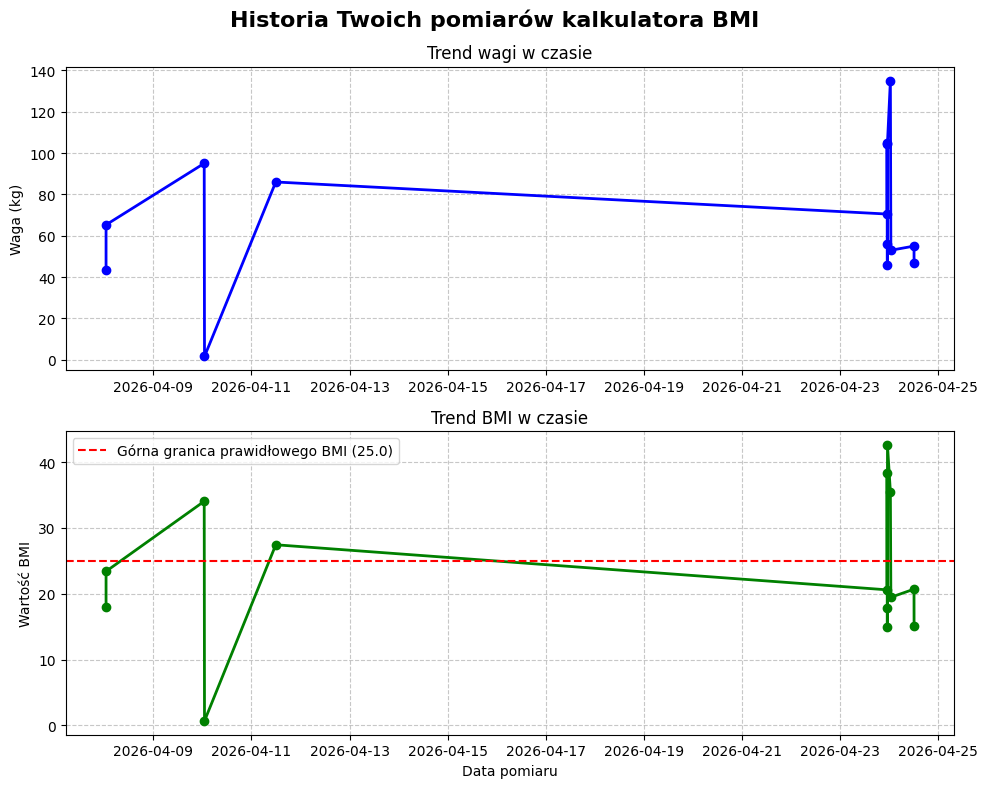


Wykres trendu BMI został wygenerowany.

----------------------------------------------------------------------



Podaj swoje dane, aby obliczyć BMI:



 -- Poziomy aktywności fizycznej --

  1. Siedzący tryb (brak lub minimalna aktywność)
  2. Lekko aktywny (lekkie ćwiczenia/sport 1-3 dni w tyg.)
  3. Umiarkowanie aktywny (ćwiczenia/sport 3-5 dni w tyg.)
  4. Bardzo aktywny (intensywne ćwiczenia/sport 6-7 dni w tyg.)
  5. Ekstremalnie aktywny (praca fizyczna / trening 2x dziennie)


                  Podsumowanie Twojego pomiaru BMI:                   


Podany wzrost: 1.65 m, podana waga: 90.0 kg
BMI: 33.06
Twoja kategoria zdrowotna: Otyłość
Zakres idealnej wagi dla Twojego wzrostu: 50.37 - 67.79 kg


                      WIZUALIZACJA BMI NA SKALI                       
         15.0[----------------------------O-----------]40.0+          
               (Niedowaga | Norma | Nadwaga | Otyłość)                


                      ZAPOTRZEBOWANIE KALORYCZNE                      


In [9]:
# =====================================================================
# GŁÓWNA APLIKACJA 
# =====================================================================

print("\n" + "=" * 70)   
print(f"{'Witaj w Kalkulatorze BMI!':^70}")
print(f"{'Autor programu: Piotr Bacior - 15 722 - 2026':^70}")
print(f"{'Oblicz swoje BMI, podając wagę w kilogramach i wzrost w metrach.':^70}")
print("=" * 70 + "\n")

czy_historia = input("Czy chcesz zobaczyć historię swoich pomiarów BMI? (T/N): ").strip().lower()    
        
if czy_historia == 't':                                 
    historia = read_history_from_file()                                                                                   
    print("\n" + "-" * 70)
    print(f"{'Historia Twoich pomiarów BMI:':^70}")     
    print("-" * 70 + "\n")

    if not historia:
        print("Brak zapisanych pomiarów BMI. Zacznij obliczać swoje BMI, aby zobaczyć historię pomiarów!")
    else:
        for linia in historia:
            print(linia.strip())

    czy_wykres = input("\nCzy chcesz zobaczyć wykres trendu swoich pomiarów BMI? (T/N): ").strip().lower()    

    if czy_wykres == 't':                                           
        print("\nGeneruję wykres trendu Twoich pomiarów BMI...")    
        
        show_bmi_trend_chart()                                      
        print("\nWykres trendu BMI został wygenerowany.")   

    print("\n" + "-" * 70 + "\n")    

print("\n" + "=" * 70 + "\n")                                       
print("Podaj swoje dane, aby obliczyć BMI:")                        
print("\n" + "=" * 70 + "\n")                                       

try:
    waga_input = input("Podaj swoją wagę w kilogramach (np. 70.5): ").replace(",", ".")
    waga = float(waga_input)

    wzrost_input = input("Podaj swój wzrost w metrach (np. 1.75): ").replace(",", ".")
    wzrost = float(wzrost_input)

    if wzrost >= 3.0:
        print(f"Informacja: Wykryto wzrost podany w centrymetrach ({wzrost} cm). Konwertuję na metry...")
        wzrost = round(wzrost / 100, 2)   

    wiek_input = input("Podaj swój wiek w latach (np. 30): ").replace(",", ".")   
    wiek = int(wiek_input)   

    plec = input("Podaj swoją płeć (M/K): ").strip().lower() 

    print('\n -- Poziomy aktywności fizycznej --\n')  
    print('  1. Siedzący tryb (brak lub minimalna aktywność)')
    print('  2. Lekko aktywny (lekkie ćwiczenia/sport 1-3 dni w tyg.)')
    print('  3. Umiarkowanie aktywny (ćwiczenia/sport 3-5 dni w tyg.)')
    print('  4. Bardzo aktywny (intensywne ćwiczenia/sport 6-7 dni w tyg.)')
    print('  5. Ekstremalnie aktywny (praca fizyczna / trening 2x dziennie)')
    
    aktywnosc_input = input("\nWybierz poziom swojej aktywności fizycznej (1-5): ").strip()  
    aktywnosc = int(aktywnosc_input)

    moje_bmi = calculate_bmi(waga, wzrost)   
    kategoria = analyze_bmi(moje_bmi)   
    min_waga, max_waga = calculate_ideal_weight(wzrost)   
    pasek_wizualny = generate_bmi_bar(moje_bmi)
    bmr = calculate_bmr(waga, wzrost, wiek, plec)   
    tdee = calculate_tdee(bmr, aktywnosc)

    save_result_to_file(waga, wzrost, moje_bmi, kategoria, min_waga, max_waga)
    save_to_csv(waga, wzrost, moje_bmi, kategoria, min_waga, max_waga)

    print("\n" + "=" * 70 + "\n")                                       
    print(f"{'Podsumowanie Twojego pomiaru BMI:':^70}")                 
    print("\n" + "=" * 70 + "\n")                                       

    print(f"Podany wzrost: {wzrost} m, podana waga: {waga} kg")         
    print(f"BMI: {moje_bmi}")                                           
    print(f"Twoja kategoria zdrowotna: {kategoria}")                    
    print(f"Zakres idealnej wagi dla Twojego wzrostu: {min_waga} - {max_waga} kg")   

    print("\n" + "=" * 70 + "\n")                                       

    print(f"{'WIZUALIZACJA BMI NA SKALI':^70}")                         
    print(f"{pasek_wizualny:^70}")                                      
    print(f"{'(Niedowaga | Norma | Nadwaga | Otyłość)':^70}")           

    print("\n" + "=" * 70 + "\n")                                       

    print(f"{'ZAPOTRZEBOWANIE KALORYCZNE':^70}")                        
    print("-" * 70)                                                     
    print(f" Podstawowa przemiana materii (BMR):      {bmr} kcal")      
    print(f" Całkowite dzienne zapotrzebowanie (TDEE): {tdee} kcal")    

    print("\n" + "=" * 70 + "\n")                                       

    print(f"{'PORADA DIETETYCZNA':^70}")
    print("-" * 70)                                                     

    if kategoria == "Niedowaga":
        print(f"Aby przybrać na wadze jedz około {tdee + 500} kcal dziennie (+500 kcal).")
    elif kategoria == "Nadwaga":
        print(f"Aby schudnąć jedz około {tdee - 500} kcal dziennie (-500 kcal).")
    elif kategoria == "Otyłość":
        print(f"Aby schudnąć jedz około {tdee - 650} kcal dziennie (-650 kcal).")
        print("W tym przypadku zalecam konsultację z lekarzem lub dietetykiem, aby opracować bezpieczny i skuteczny plan odchudzania.")
        print("Pamiętaj, że zdrowe odchudzanie to proces stopniowy, a szybka utrata wagi może być niezdrowa i trudna do utrzymania.")
    else:
        print(f"Twoje BMI jest w normie. Aby utrzymać zdrową wagę, jedz tyle kalorii, ile wynosi Twoje TDEE, czyli: {tdee} kcal dziennie.")
        print("Pamiętaj o zrównoważonej diecie i regularnej aktywności fizycznej, aby utrzymać zdrowy styl życia.")

    print("\n" + "=" * 70 + "\n")                                       

except ValueError as e:     
    print(f"\nBłąd: {e}")           
    print("Uruchom komórkę ponownie, aby wpisać poprawne dane.\n")